In [1]:
#TIME SERIES ANALYSIS
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as  sns


In [2]:
#find the available dataset names in seaborn
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [3]:
df=sns.load_dataset('flights')
print(df.head)
print(df.tail)

<bound method NDFrame.head of      year month  passengers
0    1949   Jan         112
1    1949   Feb         118
2    1949   Mar         132
3    1949   Apr         129
4    1949   May         121
..    ...   ...         ...
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432

[144 rows x 3 columns]>
<bound method NDFrame.tail of      year month  passengers
0    1949   Jan         112
1    1949   Feb         118
2    1949   Mar         132
3    1949   Apr         129
4    1949   May         121
..    ...   ...         ...
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432

[144 rows x 3 columns]>


In [4]:
#ensuring the time date column is in the correct format
#the frequency should be correct
#1949-01-01,1949-02-01 etc-------1960-12-01

In [5]:
#We get only year and month for the date we need day also
#Convert the date to a YYYY-MM--DD format in a new column named yearMonth
df['yearMonth']="01-"+df['month'].astype(str)+"-"+df['year'].astype(str)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
 3   yearMonth   144 non-null    object  
dtypes: category(1), int64(2), object(1)
memory usage: 4.0+ KB
None


In [6]:
#The new yearMonth column is of type "object" now we need to convert it to the datetime format
df['yearMonth']=pd.to_datetime(df['yearMonth'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    category      
 2   passengers  144 non-null    int64         
 3   yearMonth   144 non-null    datetime64[ns]
dtypes: category(1), datetime64[ns](1), int64(2)
memory usage: 4.0 KB


In [7]:
df.head

<bound method NDFrame.head of      year month  passengers  yearMonth
0    1949   Jan         112 1949-01-01
1    1949   Feb         118 1949-02-01
2    1949   Mar         132 1949-03-01
3    1949   Apr         129 1949-04-01
4    1949   May         121 1949-05-01
..    ...   ...         ...        ...
139  1960   Aug         606 1960-08-01
140  1960   Sep         508 1960-09-01
141  1960   Oct         461 1960-10-01
142  1960   Nov         390 1960-11-01
143  1960   Dec         432 1960-12-01

[144 rows x 4 columns]>

In [8]:
df.tail

<bound method NDFrame.tail of      year month  passengers  yearMonth
0    1949   Jan         112 1949-01-01
1    1949   Feb         118 1949-02-01
2    1949   Mar         132 1949-03-01
3    1949   Apr         129 1949-04-01
4    1949   May         121 1949-05-01
..    ...   ...         ...        ...
139  1960   Aug         606 1960-08-01
140  1960   Sep         508 1960-09-01
141  1960   Oct         461 1960-10-01
142  1960   Nov         390 1960-11-01
143  1960   Dec         432 1960-12-01

[144 rows x 4 columns]>

In [9]:
#now that the date column is in the proper format the next step is making the date column as the index column
#Making the yearMonth as the dataframe index
df.set_index('yearMonth',inplace=True)
#inplace True will make the changes permanent to the DF
print(df.head())


            year month  passengers
yearMonth                         
1949-01-01  1949   Jan         112
1949-02-01  1949   Feb         118
1949-03-01  1949   Mar         132
1949-04-01  1949   Apr         129
1949-05-01  1949   May         121


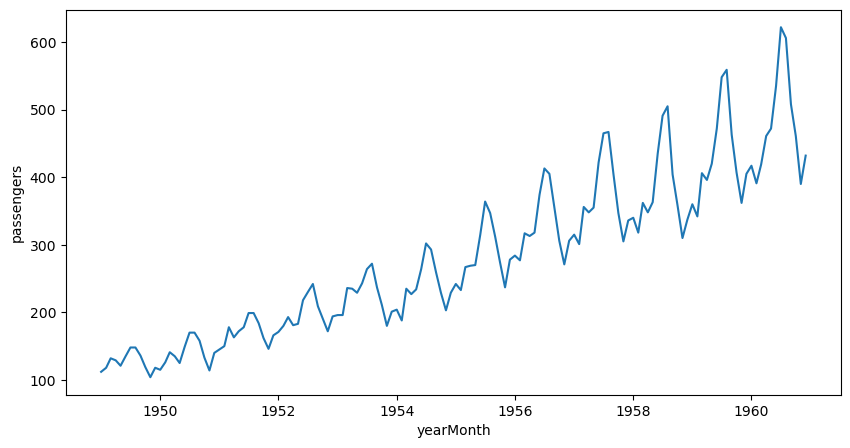

In [10]:
#now we need to visualize the time series
#visulaize the time series
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index,y=df.passengers)
plt.show()

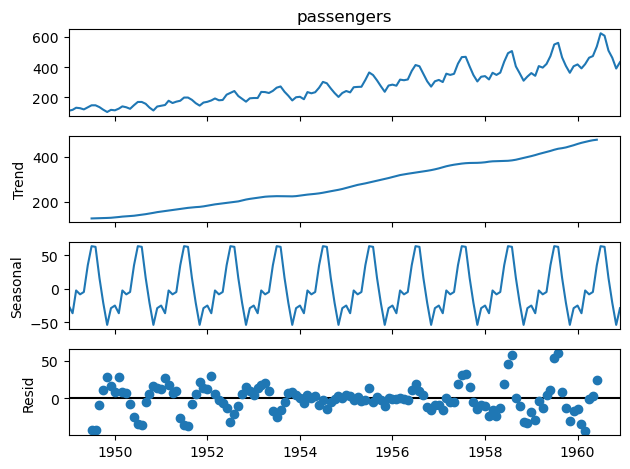

In [11]:
#now further check the seasonality and trend by doing decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(df.passengers,period=12)
fig=decomposition.plot()
plt.show()

## Trend

In [12]:
#trend is the long term nature of the time series #multi-decade movement
#either increasing (Price of gold)
#decreasing(Infant Mortality,Sales of the diesel vehicle)
#stagnant(Weather)
#we are only interested in increasing and the decreasing trends as the stagnant one signifies that it well not change in the future as well

## Seasonality

In [13]:
#some thing that happens once a year

## Residual

In [15]:
#Noise the and the irregularities after removing trend and the seasonality

In [16]:
#cyclicality which is found to occur something between 7 to 8 years 
#cylce of boom and bust
#cycle of recession and rise and then again recession                                                                    

In [17]:
#we basically do the plottingto see if there is trend and seasonality


In [18]:
#checking if the time series is stationary
#Rolling mean (Moving average) and standard deviation for 12 months
#window =12 means the rolling mean will be for last0 12 months 
df['rollMean']=df.passengers.rolling(window=12).mean()
df['rollStd']=df.passengers.rolling(window=12).std()

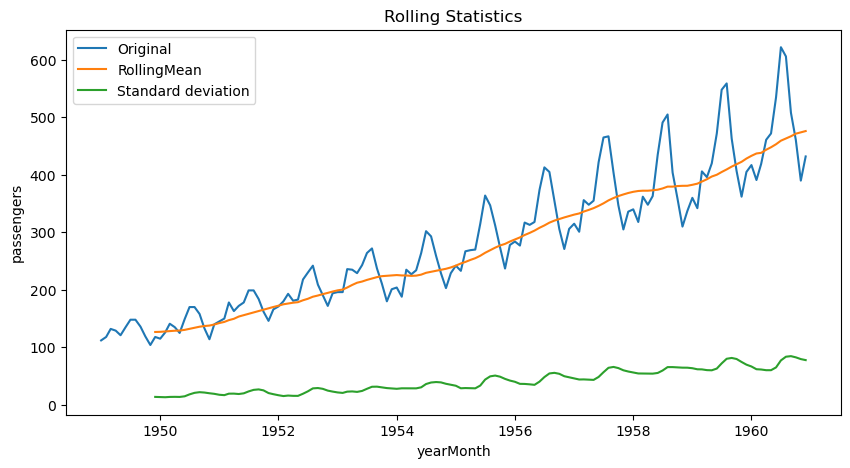

In [19]:
#plot the original series with rolling mean and std
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index,y=df.passengers,label='Original')
sns.lineplot(data=df,x=df.index,y=df.rollMean,label='RollingMean')
sns.lineplot(data=df,x=df.index,y=df.rollStd,label='Standard deviation')
plt.title("Rolling Statistics")
plt.show()

In [20]:
#rolling average will help in smoothening the data

## How do we know the time series is stationary or not

In [21]:
#the time series is stationary if the rolling mean and rolling standard deviation are in a straight like-line !) here the mean is not in a straight line 
#2) std deviation is in a straight line Conclusion) our time series is NOT stationary - if a time series is not stationary
#we cannot make predictions about the future dates

In [22]:
#checking the same using a function

In [23]:
#Define the function for the stationary check(only p-value based)
def test_stationary(dataFrame,var):
    dataFrame['rollMean']=dataFrame[var].rolling(window=12).mean()
    dataFrame['rollStd']=dataFrame[var].rolling(window=12).std()
    from statsmodels.tsa.stattools import adfuller
    adf_result=adfuller(dataFrame[var])
    p_value=adf_result[1]
    print(f"ADF p-value:{p_value:.4f}")
    if p_value < 0.05:
        print("The time series is stationary(Reject HO)")
    else: 
        print("The time series is not stationary(Fail to reject HO)")
    #plot the original series with rolling mean and std
    plt.figure(figsize=(10,5))
    sns.lineplot(data=dataFrame,x=dataFrame.index,y=var,label='Original')
    sns.lineplot(data=dataFrame,x=dataFrame.index,y='rollMean',label='Rolling Mean')
    sns.lineplot(data=dataFrame,x=dataFrame.index,y='rollStd',label='Rolling Std')
    plt.title("Stationary check using Rolling mean and Std Dev")
    plt.legend()
    plt.show()

ADF p-value:0.9919
The time series is not stationary(Fail to reject HO)


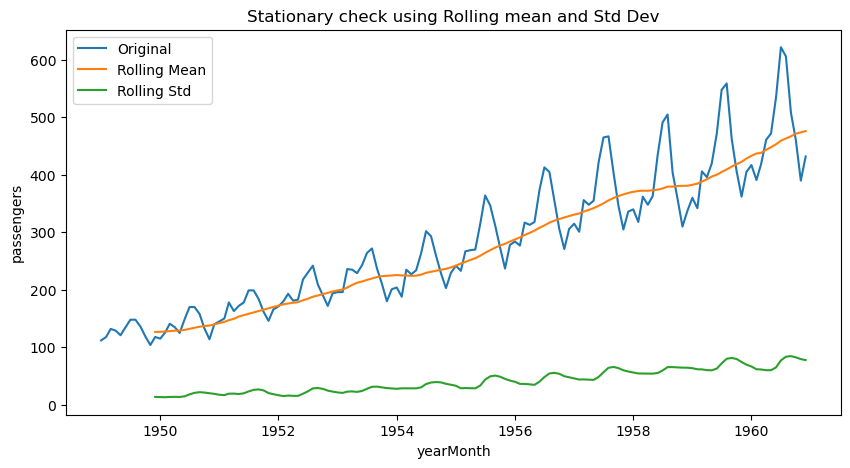

In [24]:
test_stationary(df,'passengers')

In [25]:
## how will we make the data stationary


In [26]:
#just get the passenger column into a new datafrane to perform testing
air_df=df[['passengers']].copy()

In [27]:
#try shift diff of 1
air_df['shift']=air_df.passengers.shift(1)
air_df['shiftDiff']=air_df['passengers']-air_df['shift']
print(air_df.head())


            passengers  shift  shiftDiff
yearMonth                               
1949-01-01         112    NaN        NaN
1949-02-01         118  112.0        6.0
1949-03-01         132  118.0       14.0
1949-04-01         129  132.0       -3.0
1949-05-01         121  129.0       -8.0


ADF p-value:0.0542
The time series is not stationary(Fail to reject HO)


C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_11764\1560651296.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean']=dataFrame[var].rolling(window=12).mean()
C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_11764\1560651296.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd']=dataFrame[var].rolling(window=12).std()


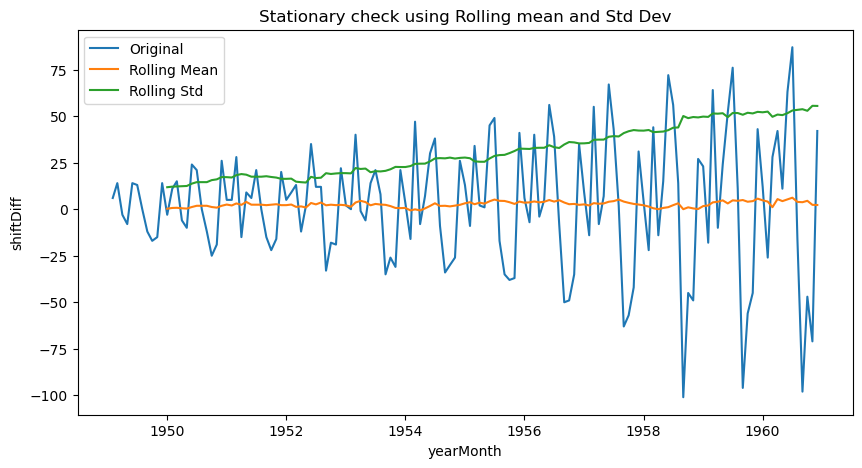

In [28]:
#Test ststionary
test_stationary(air_df.dropna(),'shiftDiff')

In [29]:
print(air_df.head())

            passengers  shift  shiftDiff
yearMonth                               
1949-01-01         112    NaN        NaN
1949-02-01         118  112.0        6.0
1949-03-01         132  118.0       14.0
1949-04-01         129  132.0       -3.0
1949-05-01         121  129.0       -8.0


In [30]:
#p-values is still >0.05 so we cannot reject H0 SO LET use shift 2

In [31]:
air_df['shift']=air_df.passengers.shift(2)
air_df['shiftDiff']=air_df['passengers']-air_df['shift']
print(air_df.head())

            passengers  shift  shiftDiff
yearMonth                               
1949-01-01         112    NaN        NaN
1949-02-01         118    NaN        NaN
1949-03-01         132  112.0       20.0
1949-04-01         129  118.0       11.0
1949-05-01         121  132.0      -11.0


ADF p-value:0.0386
The time series is stationary(Reject HO)


C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_11764\1560651296.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean']=dataFrame[var].rolling(window=12).mean()
C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_11764\1560651296.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd']=dataFrame[var].rolling(window=12).std()


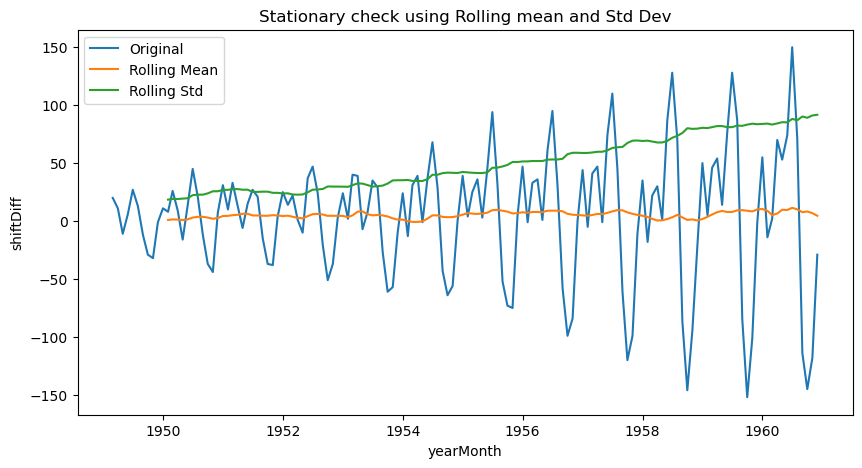

In [32]:
test_stationary(air_df.dropna(),'shiftDiff')

In [34]:
#Conclusion the data has become shomewhat stationary

In [ ]:
#beyond 3-4 shift it is not so useful as the data start to look suspiciousb

In [41]:
#Now ARIMA 
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

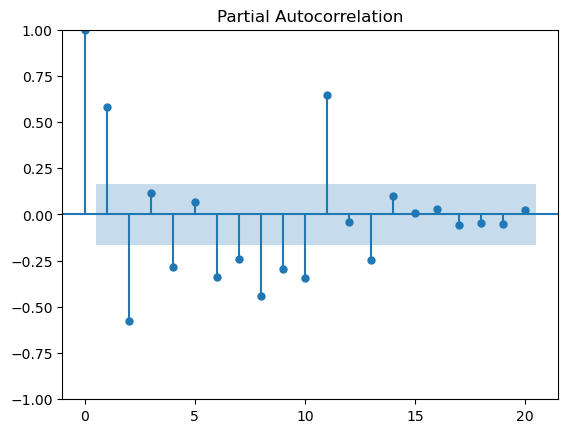

In [45]:
plot_pacf(air_df['shiftDiff'].dropna(),lags=20)
plt.show()

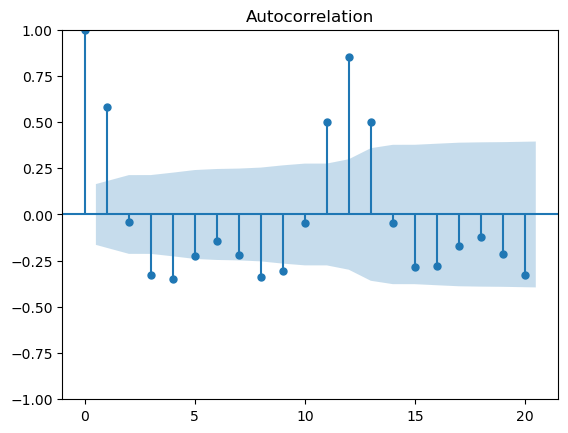

In [46]:
#Now let us take this value as p =1 amd find q, for which we need ACF
plot_acf(air_df['shiftDiff'].dropna(),lags=20)
plt.show()
# q also is 1

In [48]:
#Build ARIMA model
train= air_df[:round(len(air_df)*70/100)] #Take the first 70% data
print(train.tail()) #Just to chick where it ends 


            passengers  shift  shiftDiff
yearMonth                               
1957-01-01         315  271.0       44.0
1957-02-01         301  306.0       -5.0
1957-03-01         356  315.0       41.0
1957-04-01         348  301.0       47.0
1957-05-01         355  356.0       -1.0


In [50]:
test = air_df[round(len(air_df)*70/100):] #Take the last 30 % data starting from 71%
print(test.head()) #Just to check where it starts 

            passengers  shift  shiftDiff
yearMonth                               
1957-06-01         422  348.0       74.0
1957-07-01         465  355.0      110.0
1957-08-01         467  422.0       45.0
1957-09-01         404  465.0      -61.0
1957-10-01         347  467.0     -120.0


In [53]:
model = ARIMA(train['passengers'],order=(1,2,1)) #Parameters: p,d,q
model_fit= model.fit()
prediction= model_fit.predict(start=test.index[0],end=test.index[-1])
air_df['arimaPred']=prediction
print(air_df.tail())

            passengers  shift  shiftDiff   arimaPred
yearMonth                                           
1960-08-01         606  535.0       71.0  451.950074
1960-09-01         508  622.0     -114.0  454.403401
1960-10-01         461  606.0     -145.0  456.856728
1960-11-01         390  508.0     -118.0  459.310055
1960-12-01         432  461.0      -29.0  461.763383


C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


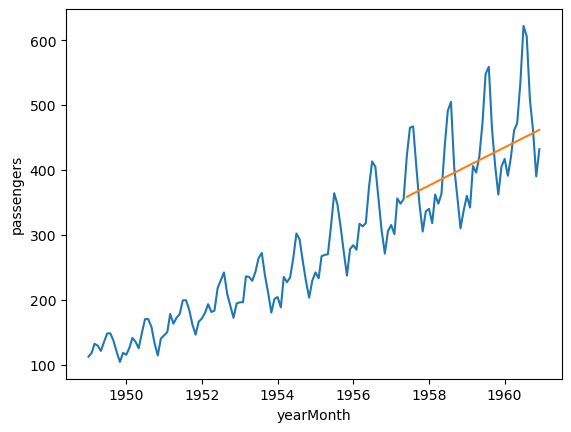

In [54]:
#Plot 
sns.lineplot(data=air_df,x=air_df.index,y='passengers')
sns.lineplot(data=air_df,x=air_df.index,y='arimaPred')
plt.show()


In [55]:
#Conclusion : The ARIMA prediction is not good 

In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train['passengers'],order=(1,2,1),seasonal_order=(1,2,1,12))
model_fit = model.fit()
prediction = model_fit.predict(start=test.index[0],end=test.index[-1])
air_df['sarimaxPred']=prediction
print(air_df.tail())
#Data looks Better 

C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\dbda.STUDENTSDC\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            passengers  shift  shiftDiff   arimaPred  sarimaxPred
yearMonth                                                        
1960-08-01         606  535.0       71.0  451.950074   588.761531
1960-09-01         508  622.0     -114.0  454.403401   518.376159
1960-10-01         461  606.0     -145.0  456.856728   452.602418
1960-11-01         390  508.0     -118.0  459.310055   402.822979
1960-12-01         432  461.0      -29.0  461.763383   450.801442


            passengers  shift  shiftDiff  arimaPred  sarimaxPred
yearMonth                                                       
1949-01-01         112    NaN        NaN        NaN          NaN
1949-02-01         118    NaN        NaN        NaN          NaN
1949-03-01         132  112.0       20.0        NaN          NaN
1949-04-01         129  118.0       11.0        NaN          NaN
1949-05-01         121  132.0      -11.0        NaN          NaN


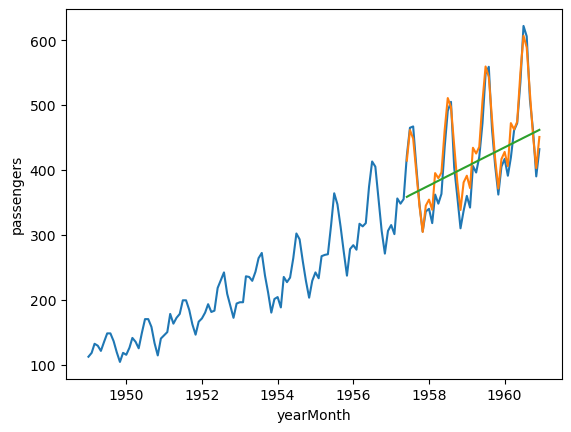

In [60]:
#Plot
air_df.dropna()
print(air_df.head())
sns.lineplot(data=air_df,x=air_df.index,y='passengers')
sns.lineplot(data=air_df,x=air_df.index,y='sarimaxPred')
sns.lineplot(data=air_df,x=air_df.index,y='arimaPred')
plt.show()

In [62]:
#SARIMAX predictions are much more accurate 

In [63]:
#Future Prediction
#First check the last date in our dataset
print(air_df.tail())

            passengers  shift  shiftDiff   arimaPred  sarimaxPred
yearMonth                                                        
1960-08-01         606  535.0       71.0  451.950074   588.761531
1960-09-01         508  622.0     -114.0  454.403401   518.376159
1960-10-01         461  606.0     -145.0  456.856728   452.602418
1960-11-01         390  508.0     -118.0  459.310055   402.822979
1960-12-01         432  461.0      -29.0  461.763383   450.801442


In [65]:
#MS Month Start frequency
#Create data froame to hold index values from 0,.01.61 to 01.12.62
futureDate=pd.DataFrame(pd.date_range(start='1961-01-01',end='1962-12-01',freq='MS'),columns=['Dates'])
futureDate.set_index('Dates',inplace=True)
print(futureDate.head())

Empty DataFrame
Columns: []
Index: [1961-01-01 00:00:00, 1961-02-01 00:00:00, 1961-03-01 00:00:00, 1961-04-01 00:00:00, 1961-05-01 00:00:00]


In [66]:
#pREDICT AND PRINT
print(model_fit.predict(start=futureDate.index[0],end=futureDate.index[-1]))

1961-01-01    462.567076
1961-02-01    437.559008
1961-03-01    508.356962
1961-04-01    497.736852
1961-05-01    511.040753
1961-06-01    591.681183
1961-07-01    652.341214
1961-08-01    632.033744
1961-09-01    555.855998
1961-10-01    485.358250
1961-11-01    432.005433
1961-12-01    482.569692
1962-01-01    494.971542
1962-02-01    466.813665
1962-03-01    541.962827
1962-04-01    530.337076
1962-05-01    545.063311
1962-06-01    630.747653
1962-07-01    694.859667
1962-08-01    672.409481
1962-09-01    590.339548
1962-10-01    515.028298
1962-11-01    458.053270
1962-12-01    511.105831
Freq: MS, Name: predicted_mean, dtype: float64


            passengers  shift  shiftDiff  arimaPred  sarimaxPred
yearMonth                                                       
1949-01-01         112    NaN        NaN        NaN          NaN
1949-02-01         118    NaN        NaN        NaN          NaN
1949-03-01         132  112.0       20.0        NaN          NaN
1949-04-01         129  118.0       11.0        NaN          NaN
1949-05-01         121  132.0      -11.0        NaN          NaN


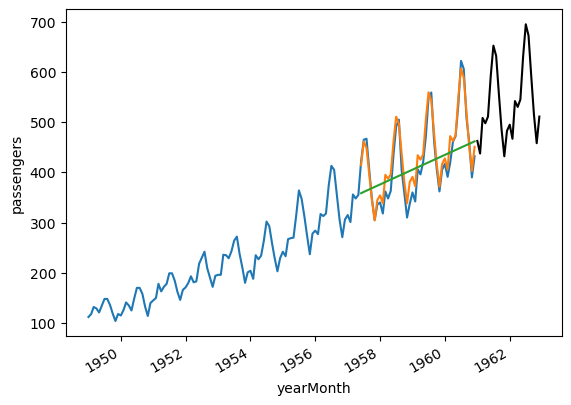

In [69]:
#plot
air_df.dropna()
print(air_df.head())
sns.lineplot(data=air_df,x=air_df.index,y='passengers')
sns.lineplot(data=air_df,x=air_df.index,y='sarimaxPred')
sns.lineplot(data=air_df,x=air_df.index,y='arimaPred')
model_fit.predict(start=futureDate.index[0],end=futureDate.index[-1]).plot(color='black')
plt.show()

In [78]:
#Model Evluation
air_df=air_df.dropna()
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score


In [82]:
#arima Evaluation
mae=mean_absolute_error(air_df['passengers'],air_df['arimaPred'])
rmse=root_mean_squared_error(air_df['passengers'],air_df['arimaPred'])
r2=r2_score(air_df['passengers'],air_df['arimaPred'])
print(f"ARIMA MAE:{mae},RMSE:{rmse},r2:{r2}")
#sarimax evaluation

ARIMA MAE:55.37963078006701,RMSE:69.01293923761835,r2:0.18946475098400184


In [ ]:
#sarimax Evalution
mae=mean_absolute_error(air_df['passengers'],air_df['sarimaxPred'])
rmse=root_mean_squared_error(air_df['passengers'],air_df['sarimaxPred'],squared=False)
r2=r2_score(air_df['passengers'],air_df['sarimaxPred'])
print(f"ARIMA MAE:{mae},RMSE:{rmse},r2:{r2}")


In [ ]:
#Next assignments:
#perform the time series analysis on
#1)Monthly Cola Production in Australia 2) ice cream sales 3)usd to inr 